<a href="https://colab.research.google.com/github/miamackk/Foundations-Of-Computer-Vision-Code/blob/main/17_Blur_Filters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
import numpy as np
from scipy.signal import convolve2d
from scipy.ndimage import uniform_filter1d, gaussian_filter
import cv2
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Chapter 17- Blur Filters

Images for this chapter: https://drive.google.com/drive/folders/1c-7zN3wHmdYTMsNOS2R6nmPMHVYex_Ow?usp=drive_link

In [ ]:
#just in case values get messed up during convolution, we normalize the color channels before merging them back together
def normalize(channel):
    mn, mx = channel.min(), channel.max()
    return ((channel - mn) / (mx - mn) * 255).astype(np.uint8)

In [ ]:
img = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 17/images/stopsign_with_noise.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
kernel = np.ones((11,11))/121.0

r, g, b = cv2.split(img)

r_conv = convolve2d(r, kernel, mode='same', boundary='symm')
g_conv = convolve2d(g, kernel, mode='same', boundary='symm')
b_conv = convolve2d(b, kernel, mode='same', boundary='symm')

blurred_img = cv2.merge((normalize(r_conv), normalize(g_conv), normalize(b_conv)))

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

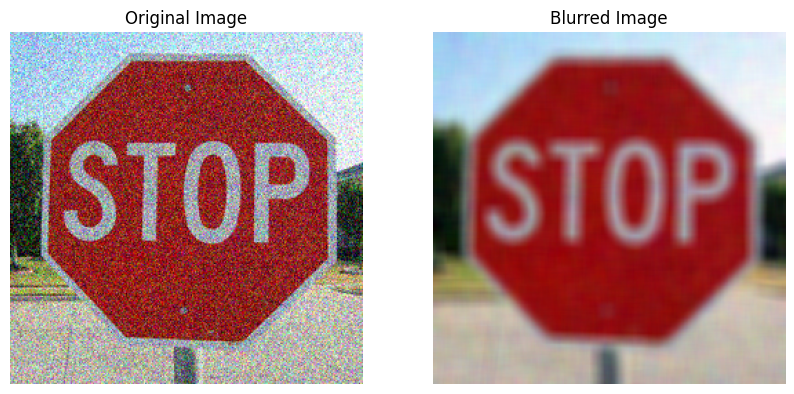

In [ ]:
# @title Figure 17.1
plt.figure(figsize=(10, 7))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blurred_img)
plt.title("Blurred Image")
plt.axis("off")

In [ ]:
people = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 17/images/convexamps.png')
people = cv2.cvtColor(people, cv2.COLOR_BGR2RGB)
r, g, b = cv2.split(people)

In [ ]:
#axis = 1 for horizontal blur
r_conv_h = uniform_filter1d(r, size=15, axis = 1)
g_conv_h = uniform_filter1d(g, size=15, axis = 1)
b_conv_h = uniform_filter1d(b, size=15, axis = 1)

horizontal_blur = cv2.merge((r_conv_h, g_conv_h, b_conv_h))

#axis = 0 for vertical
r_conv_v = uniform_filter1d(r, size=15, axis = 0)
g_conv_v = uniform_filter1d(g, size=15, axis = 0)
b_conv_v = uniform_filter1d(b, size=15, axis = 0)

vertical_blur = cv2.merge((r_conv_v, g_conv_v, b_conv_v))

#box blur

kernel = np.ones((15,15))/225.0

r_conv = convolve2d(r, kernel, mode='same', boundary='symm')
g_conv = convolve2d(g, kernel, mode='same', boundary='symm')
b_conv = convolve2d(b, kernel, mode='same', boundary='symm')

box_blur = cv2.merge((r_conv, g_conv, b_conv))
box_blur = np.clip(box_blur, 0, 255).astype(np.uint8)

(np.float64(-0.5), np.float64(234.5), np.float64(234.5), np.float64(-0.5))

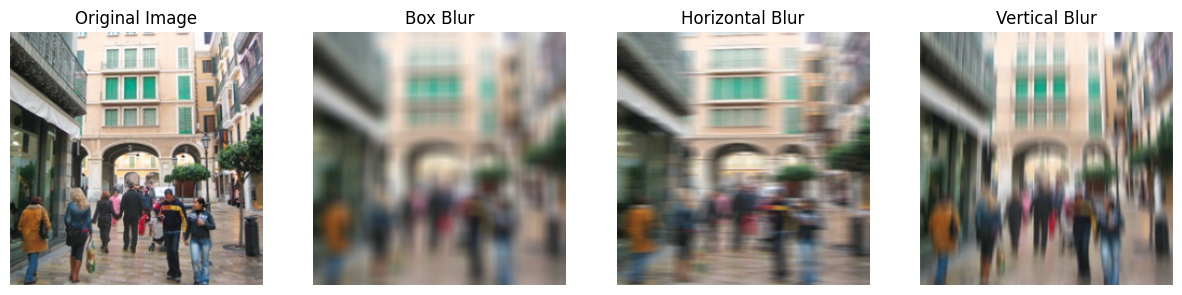

In [ ]:
# @title Figure 17.2
plt.figure(figsize=(15, 5))

plt.subplot(1,4,1)
plt.imshow(people)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(box_blur)
plt.title("Box Blur")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(horizontal_blur)
plt.title("Horizontal Blur")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(vertical_blur)
plt.title("Vertical Blur")
plt.axis("off")

In [ ]:
zebra = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 17/images/zebra2.png')
zebra = cv2.cvtColor(zebra, cv2.COLOR_BGR2RGB)
r, g, b = cv2.split(zebra)

In [ ]:
#sigma 2
r_4 = gaussian_filter(r, 4, mode = "reflect")
g_4 = gaussian_filter(g, 4, mode = "reflect")
b_4 = gaussian_filter(b, 4, mode = "reflect")

blur_2 = cv2.merge((r_4, g_4, b_4))

#sigma 4
r_8 = gaussian_filter(r, 8, mode = "reflect")
g_8 = gaussian_filter(g, 8, mode = "reflect")
b_8 = gaussian_filter(b, 8, mode = "reflect")

blur_4 = cv2.merge((r_8, g_8, b_8))

#sigma 8
r_16 = gaussian_filter(r, 16, mode = "reflect")
g_16 = gaussian_filter(g, 16, mode = "reflect")
b_16 = gaussian_filter(b, 16, mode = "reflect")

blur_8 = cv2.merge((r_16, g_16, b_16))

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

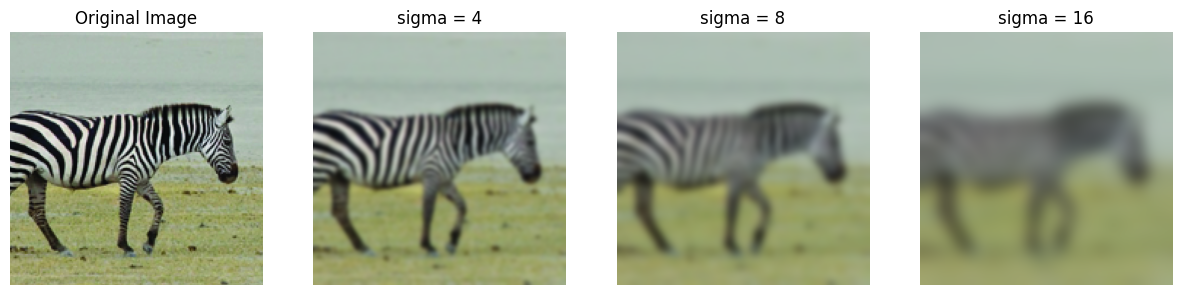

In [ ]:
# @title Figure 17.4
plt.figure(figsize=(15, 5))

plt.subplot(1,4,1)
plt.imshow(zebra)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(blur_2)
plt.title("sigma = 4")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(blur_4)
plt.title("sigma = 8")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(blur_8)
plt.title("sigma = 16")
plt.axis("off")

In [ ]:
lincoln = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 17/images/linc_pix.png', cv2.IMREAD_GRAYSCALE)

In [ ]:
blur = gaussian_filter(lincoln, 2, mode = "reflect")

(np.float64(-0.5), np.float64(51.5), np.float64(71.5), np.float64(-0.5))

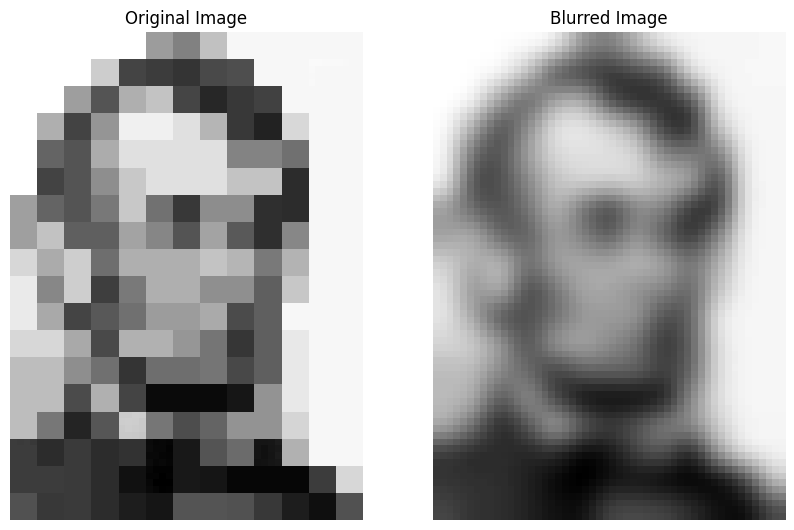

In [ ]:
# @title Figure 17.5
plt.figure(figsize=(10, 8))
plt.set_cmap("gray")

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(lincoln)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Blurred Image")
plt.imshow(blur)
plt.axis("off")

In [ ]:
boat = cv2.imread('/content/drive/MyDrive/Foundations Of Computer Vision Code/Chapter 17/images/boat_b_noise.png')
boat = cv2.cvtColor(boat, cv2.COLOR_BGR2RGB)
r, g, b = boat[:,:,0], boat[:,:,1], boat[:,:,2]

In [ ]:
# 3x3 box filter
# looks like:
'''[[1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]]
'''

kernel = np.ones((3, 3))/9.0

r_conv = convolve2d(r, kernel, mode='same', boundary='symm')
g_conv = convolve2d(g, kernel, mode='same', boundary='symm')
b_conv = convolve2d(b, kernel, mode='same', boundary='symm')

box_blur = cv2.merge((normalize(r_conv), normalize(g_conv), normalize(b_conv)))

#3x3 binomial filter

binomial_kernel = np.array([[1, 2, 1],
                            [2, 4, 2],
                            [1, 2, 1]])/16.0

r_conv = convolve2d(r, binomial_kernel, mode='same', boundary='symm')
g_conv = convolve2d(g, binomial_kernel, mode='same', boundary='symm')
b_conv = convolve2d(b, binomial_kernel, mode='same', boundary='symm')

binomial_blur = cv2.merge((normalize(r_conv), normalize(g_conv), normalize(b_conv)))


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

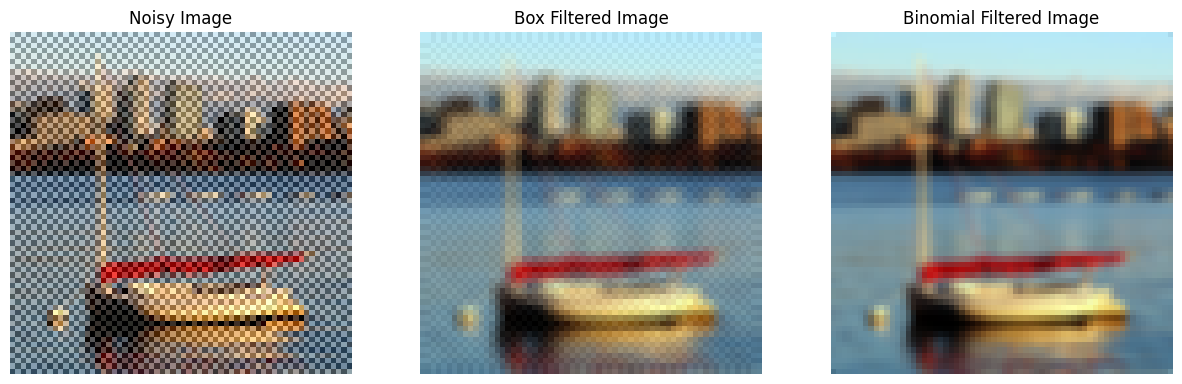

In [ ]:
# @title Figure 17.8
plt.figure(figsize=(15, 8))

plt.subplot(1, 3, 1)
plt.title("Noisy Image")
plt.imshow(boat)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Box Filtered Image")
plt.imshow(box_blur)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Binomial Filtered Image")
plt.imshow(binomial_blur)
plt.axis("off")